# Phase Diagrams & Scaling Laws

Visualize MSE and nonlinear_gain as smooth functions of (n, m, l, S) using the **precise CSV** (consistent eval).

Then fit scaling laws of varying simplicity:
- **Most accurate**: gradient-boosted regression or polynomial in log-space
- **Simplest**: power law in m/n and 1−S
- Show the **Pareto frontier** simplicity vs accuracy

Goal: a few clean equations a reader can carry around in their head.


In [1]:
import os, sys
sys.path.insert(0, '../code')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

# Load both noisy and precise CSVs; use precise everywhere
precise = pd.read_csv('results_db/compiled/sweep_results_precise.csv')
noisy = pd.read_csv('results_db/compiled/sweep_results.csv')
# Use the new clean pct_nonlinear_mse_decrease from precise CSV (vs the old
# 'nonlinear_gain' from noisy CSV which uses linear shadow of encoder).
df = precise.copy()
df['nonlinear_gain'] = df['pct_nonlinear_mse_decrease']  # alias used below for backward-compat plotting
# Also pull linearity_score from noisy as a side metric
lin_scores = noisy[['n','m','l','S','linearity_score']]
df = df.merge(lin_scores, on=['n','m','l','S'], how='left')
df['log_mse'] = np.log10(df['mse_full'])
df['compression'] = df['m'] / df['n']
df['sparsity'] = df['S']
df['density'] = 1 - df['S']  # fraction active
print(f'{len(df)} configs')
print(df.head())


216 configs
    n  m  l     S  mse_full  nonlinear_mse_decrease  \
0  16  2  1  0.85  0.033551                0.000000   
1  16  2  1  0.90  0.022849                0.000000   
2  16  2  1  0.95  0.011555                0.000000   
3  16  2  2  0.85  0.019704                0.013847   
4  16  2  2  0.90  0.012067                0.010782   

   pct_nonlinear_mse_decrease  nonlinear_gain  linearity_score   log_mse  \
0                    0.000000        0.000000         1.000000 -1.474299   
1                    0.000000        0.000000         1.000000 -1.641129   
2                    0.000000        0.000000         1.000000 -1.937224   
3                    0.412723        0.412723         0.513680 -1.705456   
4                    0.471869        0.471869         0.837771 -1.918387   

   compression  sparsity  density  
0        0.125      0.85     0.15  
1        0.125      0.90     0.10  
2        0.125      0.95     0.05  
3        0.125      0.85     0.15  
4        0.125      

## 1. Phase diagrams (heatmaps) — MSE on log scale

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_58382/172793227.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


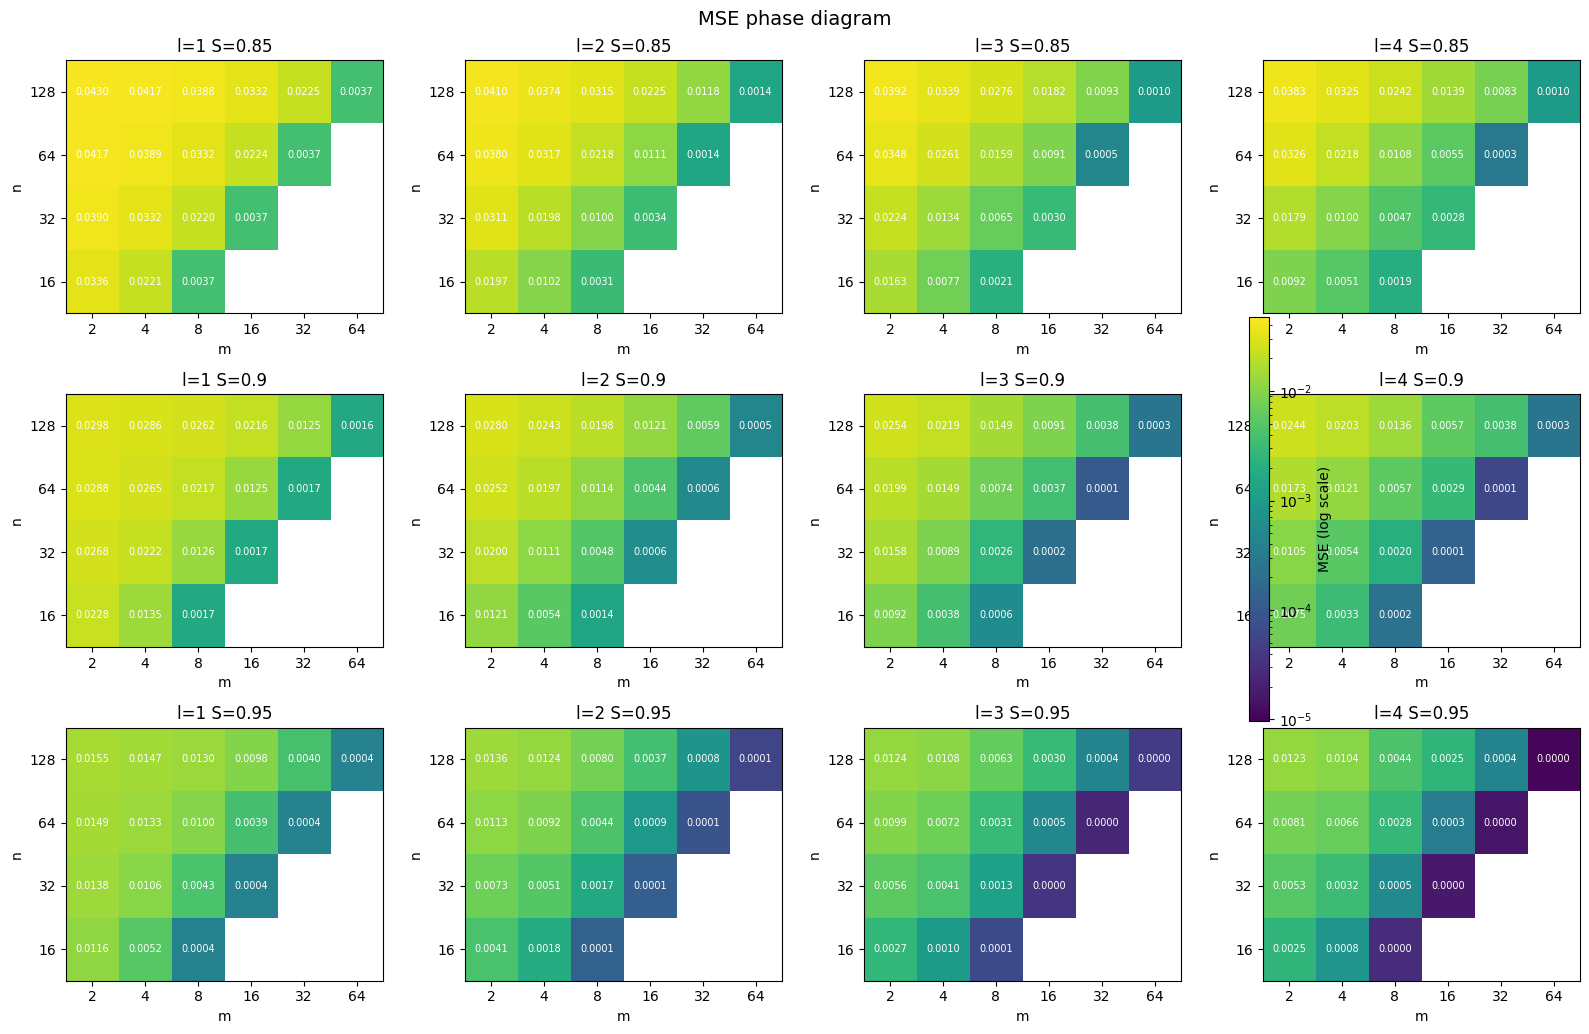

saved fig_phase_diagram_mse.png


In [2]:
def heatmap_mse_grid(df, S_values, l_values, save_path):
    n_vals = sorted(df['n'].unique())
    m_vals = sorted(df['m'].unique())
    fig, axes = plt.subplots(len(S_values), len(l_values), figsize=(4*len(l_values), 3.5*len(S_values)), squeeze=False)
    
    # Get global mse range for consistent colormap
    vmin = df['mse_full'].min() * 0.9
    vmax = df['mse_full'].max() * 1.1
    
    for i, S in enumerate(S_values):
        for j, l in enumerate(l_values):
            sub = df[(df.S == S) & (df.l == l)]
            pivot = sub.pivot_table(values='mse_full', index='n', columns='m', aggfunc='first')
            # reorder rows/cols
            pivot = pivot.reindex(n_vals).reindex(m_vals, axis=1)
            ax = axes[i, j]
            im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                           norm=LogNorm(vmin=vmin, vmax=vmax), cmap='viridis')
            ax.set_xticks(range(len(m_vals))); ax.set_xticklabels(m_vals)
            ax.set_yticks(range(len(n_vals))); ax.set_yticklabels(n_vals)
            ax.set_xlabel('m')
            ax.set_ylabel('n')
            ax.set_title(f'l={l} S={S}')
            # Annotate
            for ii in range(len(n_vals)):
                for jj in range(len(m_vals)):
                    val = pivot.values[ii, jj]
                    if not np.isnan(val):
                        ax.text(jj, ii, f'{val:.4f}', ha='center', va='center',
                                fontsize=7, color='white')
    fig.suptitle('MSE phase diagram', fontsize=14)
    fig.colorbar(im, ax=axes, shrink=0.5, label='MSE (log scale)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()
    print('saved', save_path)


heatmap_mse_grid(df, S_values=[0.85, 0.9, 0.95], l_values=[1, 2, 3, 4],
                 save_path='fig_phase_diagram_mse.png')


## 2. MSE as a function of m/n (compression ratio) at fixed S, l

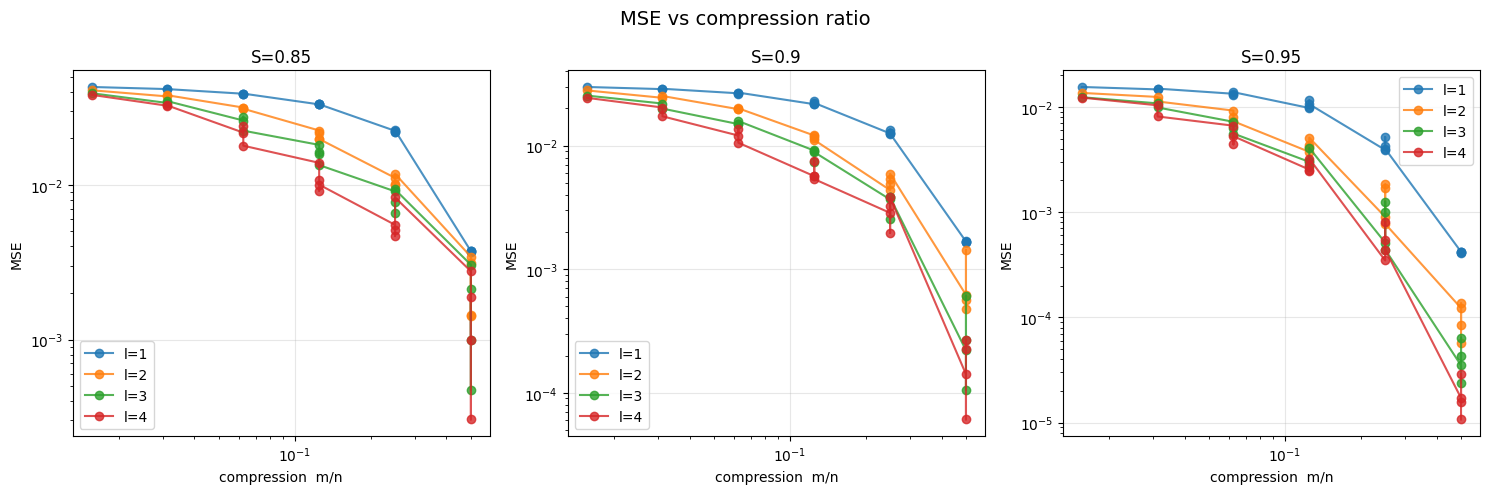

saved fig_loss_vs_compression.png


In [3]:
def plot_loss_vs_compression(df, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, S in zip(axes, [0.85, 0.9, 0.95]):
        sub = df[df.S == S]
        for l in [1, 2, 3, 4]:
            ls = sub[sub.l == l].sort_values('compression')
            ax.plot(ls['compression'], ls['mse_full'], 'o-', label=f'l={l}', alpha=0.8)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('compression  m/n')
        ax.set_ylabel('MSE')
        ax.set_title(f'S={S}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle('MSE vs compression ratio', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()
    print('saved', save_path)

plot_loss_vs_compression(df, 'fig_loss_vs_compression.png')


## 3. Nonlinear gain phase diagram

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_58382/3236197995.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


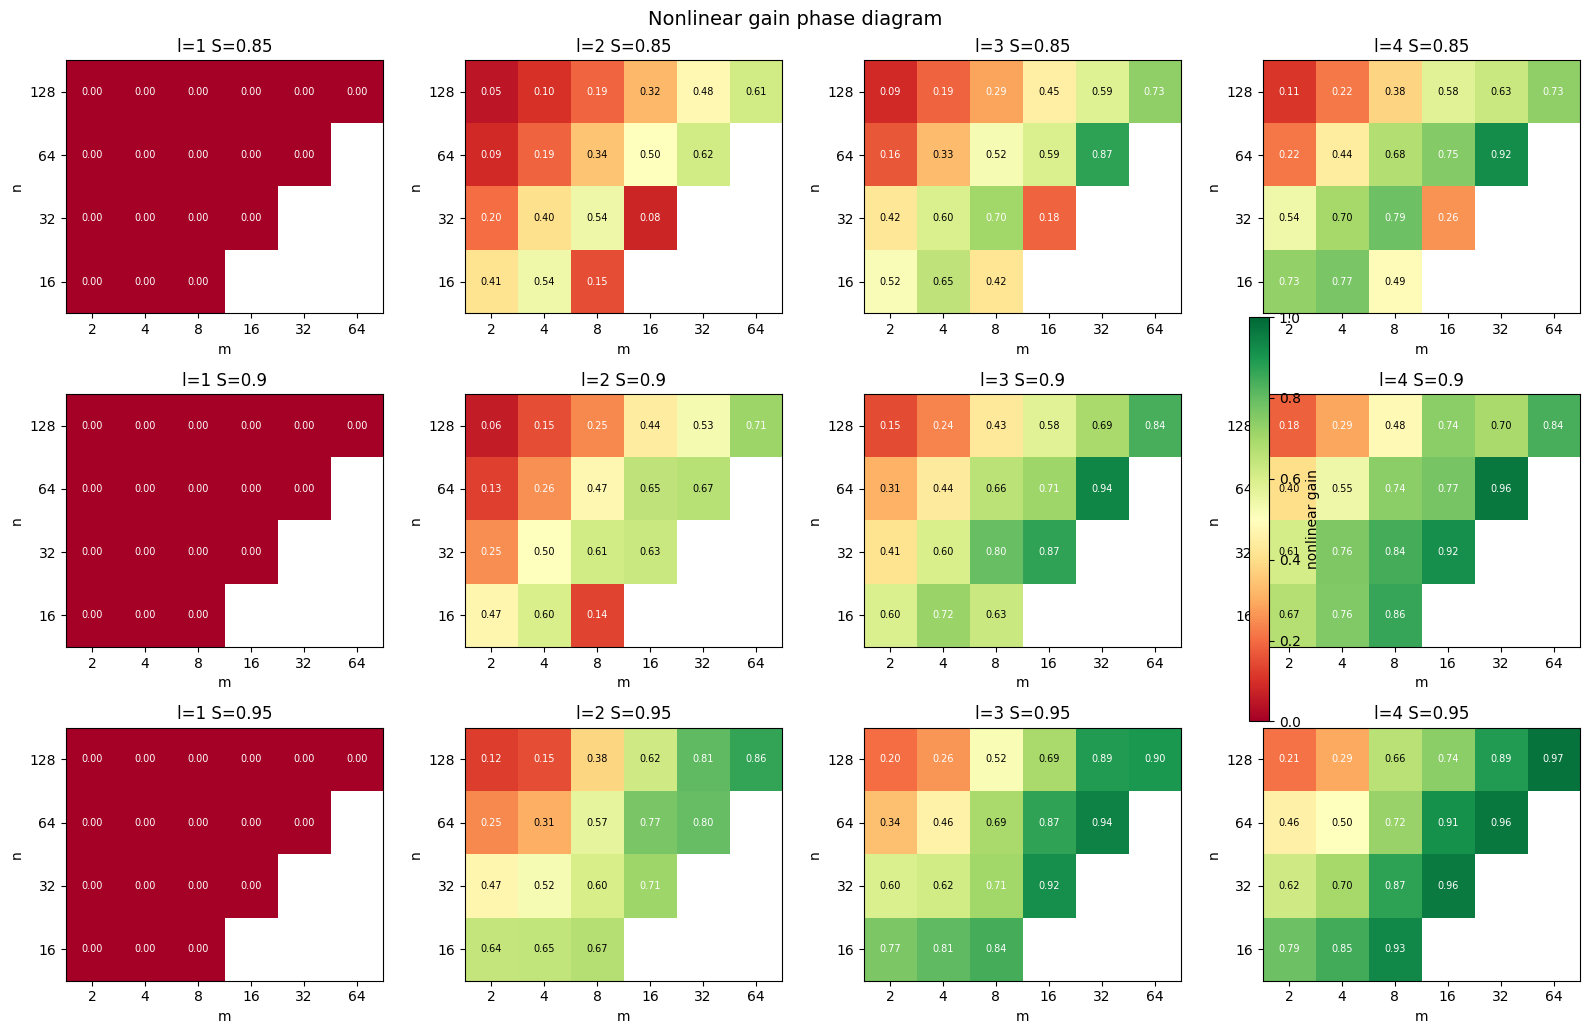

saved fig_phase_diagram_gain.png


In [4]:
def heatmap_gain_grid(df, S_values, l_values, save_path):
    n_vals = sorted(df['n'].unique())
    m_vals = sorted(df['m'].unique())
    fig, axes = plt.subplots(len(S_values), len(l_values), figsize=(4*len(l_values), 3.5*len(S_values)), squeeze=False)
    for i, S in enumerate(S_values):
        for j, l in enumerate(l_values):
            sub = df[(df.S == S) & (df.l == l)]
            pivot = sub.pivot_table(values='nonlinear_gain', index='n', columns='m', aggfunc='first')
            pivot = pivot.reindex(n_vals).reindex(m_vals, axis=1)
            ax = axes[i, j]
            im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                           vmin=0, vmax=1, cmap='RdYlGn')
            ax.set_xticks(range(len(m_vals))); ax.set_xticklabels(m_vals)
            ax.set_yticks(range(len(n_vals))); ax.set_yticklabels(n_vals)
            ax.set_xlabel('m'); ax.set_ylabel('n')
            ax.set_title(f'l={l} S={S}')
            for ii in range(len(n_vals)):
                for jj in range(len(m_vals)):
                    val = pivot.values[ii, jj]
                    if not np.isnan(val):
                        ax.text(jj, ii, f'{val:.2f}', ha='center', va='center', fontsize=7,
                                color='black' if 0.3 < val < 0.7 else 'white')
    fig.suptitle('Nonlinear gain phase diagram', fontsize=14)
    fig.colorbar(im, ax=axes, shrink=0.5, label='nonlinear gain')
    plt.tight_layout()
    plt.savefig(save_path, dpi=80, bbox_inches='tight')
    plt.show()
    print('saved', save_path)

heatmap_gain_grid(df, S_values=[0.85, 0.9, 0.95], l_values=[1, 2, 3, 4],
                 save_path='fig_phase_diagram_gain.png')


## 4. Scaling-law fits

Fit log10(MSE) = f(features). Try several models of increasing complexity, compute the R² each achieves, and chart the simplicity-vs-accuracy Pareto.

Features considered (all in log space where signed):
- log10(m/n)  — compression
- log10(1−S)  — density
- l           — depth


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

X_all = df.copy()
X_all = X_all[(X_all['mse_full'] > 0) & (X_all['nonlinear_gain'].notna())].copy()
X_all['log_compression'] = np.log10(X_all['compression'])
X_all['log_density'] = np.log10(X_all['density'])

y = X_all['log_mse'].values

def fit_and_score(feature_cols, name, model_cls=LinearRegression):
    X = X_all[feature_cols].values
    m = model_cls()
    m.fit(X, y)
    yhat = m.predict(X)
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    rmse = np.sqrt(((y - yhat) ** 2).mean())
    coef_str = ''
    if hasattr(m, 'coef_'):
        coef_str = '  '.join(f'{c:+.3f}*{f}' for c, f in zip(m.coef_, feature_cols)) + f'  +  {m.intercept_:+.3f}'
    return dict(name=name, n_params=len(feature_cols) + 1, r2=r2, rmse=rmse, coef=coef_str)

results = []
results.append(fit_and_score(['log_compression'], 'log_mse ~ log(m/n)'))
results.append(fit_and_score(['log_density'], 'log_mse ~ log(1-S)'))
results.append(fit_and_score(['l'], 'log_mse ~ l'))
results.append(fit_and_score(['log_compression', 'log_density'], 'log_mse ~ log(m/n) + log(1-S)'))
results.append(fit_and_score(['log_compression', 'log_density', 'l'], 'log_mse ~ log(m/n) + log(1-S) + l'))
results.append(fit_and_score(['log_compression', 'log_density', 'l', 'n'],
                              'log_mse ~ log(m/n) + log(1-S) + l + n'))
# Interaction term
X_all['lc_x_l'] = X_all['log_compression'] * X_all['l']
X_all['lc_x_ld'] = X_all['log_compression'] * X_all['log_density']
results.append(fit_and_score(['log_compression', 'log_density', 'l', 'lc_x_l', 'lc_x_ld'],
                              'log_mse ~ above + lc*l + lc*ld'))

# Most accurate: GBR
results.append(fit_and_score(['log_compression', 'log_density', 'l', 'n', 'm'], 
                              'GBR (5 features)', model_cls=lambda: GradientBoostingRegressor(n_estimators=300, max_depth=4)))

print(f'{"Model":<45} {"params":>7} {"R²":>7} {"RMSE":>9}  coef')
print('-' * 100)
for r in results:
    print(f'{r["name"]:<45} {r["n_params"]:>7} {r["r2"]:>7.4f} {r["rmse"]:>9.4f}  {r["coef"][:60]}')


Model                                          params      R²      RMSE  coef
----------------------------------------------------------------------------------------------------
log_mse ~ log(m/n)                                  2  0.5279    0.5403  -1.277*log_compression  +  -3.426
log_mse ~ log(1-S)                                  2  0.1923    0.7068  +1.751*log_density  +  -0.492
log_mse ~ l                                         2  0.0735    0.7570  -0.191*l  +  -1.839
log_mse ~ log(m/n) + log(1-S)                       3  0.7202    0.4160  -1.277*log_compression  +1.751*log_density  +  -1.602
log_mse ~ log(m/n) + log(1-S) + l                   4  0.7937    0.3572  -1.277*log_compression  +1.751*log_density  -0.191*l  +  -1.
log_mse ~ log(m/n) + log(1-S) + l + n               5  0.8031    0.3489  -1.341*log_compression  +1.751*log_density  -0.191*l  -0.002
log_mse ~ above + lc*l + lc*ld                      6  0.8379    0.3167  +0.748*log_compression  +2.996*log_density  -0.376

## 5. Pareto frontier

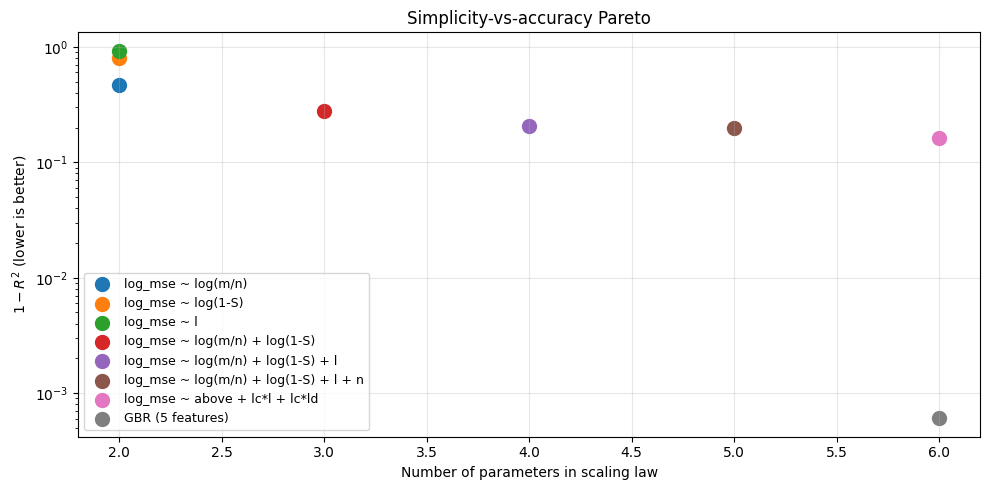

saved fig_scaling_pareto.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for r in results:
    ax.scatter(r['n_params'], 1 - r['r2'], s=100, label=r['name'])
ax.set_xlabel('Number of parameters in scaling law')
ax.set_ylabel(r'$1 - R^2$ (lower is better)')
ax.set_yscale('log')
ax.set_title('Simplicity-vs-accuracy Pareto')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_scaling_pareto.png', dpi=80, bbox_inches='tight')
plt.show()
print('saved fig_scaling_pareto.png')


## 6. Predicted vs. observed (best linear model)

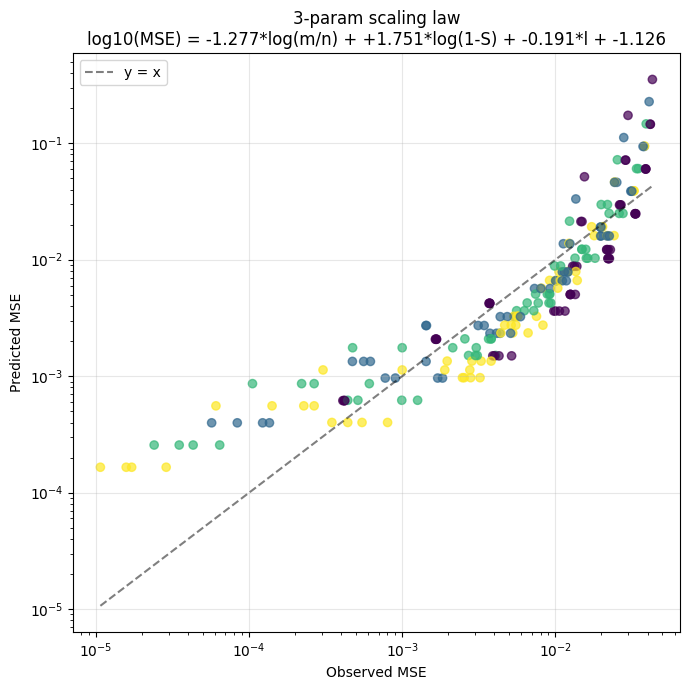

saved fig_scaling_predicted_vs_observed.png


In [7]:
# Re-fit the best clean linear model for predictions
best = LinearRegression()
features = ['log_compression', 'log_density', 'l']
best.fit(X_all[features].values, y)
yhat = best.predict(X_all[features].values)
mse_pred = 10 ** yhat
mse_obs = 10 ** y

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(mse_obs, mse_pred, c=X_all['l'], cmap='viridis', alpha=0.7)
xline = np.logspace(np.log10(mse_obs.min()), np.log10(mse_obs.max()), 100)
ax.plot(xline, xline, 'k--', alpha=0.5, label='y = x')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Observed MSE')
ax.set_ylabel('Predicted MSE')
formula = f'log10(MSE) = {best.coef_[0]:+.3f}*log(m/n) + {best.coef_[1]:+.3f}*log(1-S) + {best.coef_[2]:+.3f}*l + {best.intercept_:+.3f}'
ax.set_title(f'3-param scaling law\n{formula}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_scaling_predicted_vs_observed.png', dpi=80, bbox_inches='tight')
plt.show()
print('saved fig_scaling_predicted_vs_observed.png')
